# AR(10) Market Cap Rank Prediction — All Rebalance Years (2006–2025)

---

## Overview

This notebook extends the single-year baseline study (`01_ranking_predictions_easy.ipynb`) across all 20 Russell annual reconstitutions from 2006 to 2025. The core question is simple:

> **Can a purely mechanical time-series model predict which stocks will be in the Russell 2000 at rebalance time, using only their own historical market cap trajectory?**

The answer is expected to be **no** — and quantifying *how badly* it fails across different market regimes is the point. A model with no fundamental signal (earnings, analyst estimates, sector rotation) serves as a natural lower bound against which any smarter prediction approach can be benchmarked.

---

## Methodology

| Parameter | Value | Rationale |
|---|---|---|
| Model | AR(10) on first-differences | Simple, parsimonious; standard baseline for financial time series |
| t = 0 | Russell Rank Date (~late April / May) | The date FTSE Russell uses to snapshot market caps for index construction |
| Training window | Up to 315 trading days before rank date | ~15 months; long enough to estimate 10 AR coefficients, short enough to stay in-regime |
| Forecast horizon | **60 trading days** after rank date | ~3 calendar months; longer than the 30-day baseline to make the task harder and stress-test the model |
| Target | Rank each stock's predicted market cap, compare to actual ranks at the target date | Rank correlation (Spearman ρ) and absolute rank error are the primary metrics |

### Why first-differences?
Market cap levels are non-stationary (they drift with the market). Fitting AR on first-differences (daily $ changes) makes the series approximately stationary, which is a requirement for OLS estimates to be meaningful. The predicted level is then reconstructed as `last_observed_cap + cumulative_forecasted_changes`.

### Why 60 days?
The Russell effective date is typically ~17 trading days after the rank date. A 60-day horizon overshoots the effective date deliberately — it tests whether the model can anticipate the *direction* of market cap drift well enough to predict index membership, not just track the recent trend.

---

## Expected Results

- **Spearman ρ** will be high (0.85–0.95) because the *level* of market cap is already known at t=0 and most stocks don't move drastically in 60 days. This does **not** mean the model is good — it reflects persistence of the size hierarchy, not model skill.
- **Mean Absolute Rank Error** will be large (200–400 positions) because rank is sensitive to relative movement, and the AR model has no way to predict which specific stocks will outperform.
- **Add/remove recall** for Russell 2000 will be low — the stocks that actually enter or exit are disproportionately the ones that moved the most, which is exactly what a naive time-series model cannot predict.

---

## 1. Setup

Standard imports plus path configuration. All data paths resolve relative to `../../data/` from this notebook's location inside `notebooks/predictions/`. Key parameters are defined here so they can be changed in one place.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import spearmanr
from pathlib import Path

sns.set_theme(style='whitegrid', font_scale=1.05)

# ── Data paths ────────────────────────────────────────────────────────────────
PROCESSED_DIR  = Path('../../data/processed')
RAW_PRICES_DIR = Path('../../data/raw/prices')
RAW_MBR_DIR    = Path('../../data/raw/membership')

MCAPS_CSV     = RAW_PRICES_DIR / 'FINALIZED_MCAPS_CSV.csv'
MCAPS_PARQUET = PROCESSED_DIR  / 'FINALIZED_MCAPS.parquet'
CALENDAR_FILE = RAW_MBR_DIR    / 'russell_calendar.xlsx'

# ── Model parameters ─────────────────────────────────────────────────────────
LAGS       = 10   # AR order
STEPS      = 60   # forecast horizon in trading days (~3 calendar months)
TRAIN_DAYS = 315  # max training window (≈15 months of trading days)
MIN_OBS    = LAGS + 2  # minimum non-NaN observations required to fit

---

## 2. Data Loading

### 2.1 Market Cap Matrix

The source file `FINALIZED_MCAPS_CSV.csv` contains daily market caps (in USD millions) for ~11,500 Bloomberg tickers from January 2006 to mid-2026. It is exported from Bloomberg in wide format: rows = dates, columns = tickers, values = market cap.

**Why convert to Parquet?**  
The CSV is ~400 MB and takes 30–60 seconds to parse with `pd.read_csv`. Parquet is a columnar binary format — once written, it loads in a few seconds. The conversion runs once and is skipped on subsequent executions.

In [2]:
if not MCAPS_PARQUET.exists():
    print('Converting MCAPS CSV → Parquet (one-time, ~30s)...')
    _m = pd.read_csv(
        MCAPS_CSV,
        index_col=0,
        na_values=['#N/A N/A', '#N/A', 'N/A', '#NA'],
        encoding='utf-8-sig'       # handles Bloomberg's UTF-8 BOM header
    )
    _m.index = pd.to_datetime(_m.index)
    _m = _m.apply(pd.to_numeric, errors='coerce')
    _m.sort_index().to_parquet(MCAPS_PARQUET)
    print(f'Done. Shape: {_m.shape}')
else:
    print('Parquet already exists — skipping conversion.')

Parquet already exists — skipping conversion.


In [3]:
mcaps = pd.read_parquet(MCAPS_PARQUET)
print(f'Market cap matrix: {mcaps.shape[0]:,} dates × {mcaps.shape[1]:,} tickers')
print(f'Date range       : {mcaps.index.min().date()} → {mcaps.index.max().date()}')
print(f'Coverage         : {mcaps.notna().mean().mean():.1%} of cells non-NaN')

Market cap matrix: 5,310 dates × 11,545 tickers
Date range       : 2006-01-02 → 2026-05-08
Coverage         : 79.0% of cells non-NaN


### 2.2 Russell Rebalance Calendar

The Russell Calendar provides the official **Rank Date** for each annual reconstitution — the snapshot date FTSE Russell uses to rank all eligible securities by market cap before constructing the index. This is our `t = 0`.

Key dates in the rebalance cycle:
- **Rank Date** (t = 0): market cap snapshot, late April or May
- **Announcement Date** (~t + 23 trading days): preliminary additions/deletions published
- **Effective Date** (~t + 38 trading days): index officially reconstitutes, typically last Friday of June

In [4]:
_cal_raw = pd.read_excel(CALENDAR_FILE, sheet_name='Russell Calendar', header=3)
_cal_raw.columns = ['Year', 'Period', 'Rank_Date', 'Announcement_Date',
                    'Effective_Date', 'Effective_Open', 'Notes']
calendar = (
    _cal_raw[['Year', 'Rank_Date', 'Effective_Date']]
    .dropna(subset=['Year'])
    .assign(
        Year          = lambda d: d['Year'].astype(int),
        Rank_Date     = lambda d: pd.to_datetime(d['Rank_Date']),
        Effective_Date= lambda d: pd.to_datetime(d['Effective_Date']),
    )
    .set_index('Year')
)
calendar

,Rank_Date,Effective_Date
Year,,
2006,2006-05-31,2006-06-30
2007,2007-05-31,2007-06-22
2008,2008-05-30,2008-06-27
2009,2009-05-29,2009-06-26
2010,2010-05-28,2010-06-25
2011,2011-05-31,2011-06-24
2012,2012-05-31,2012-06-22
2013,2013-05-31,2013-06-28
2014,2014-05-30,2014-06-27


---

## 3. Model Definition

### 3.1 AR(10) Forecaster

The model for each stock is an **autoregression of order 10** estimated on daily first-differences of market cap:

$$\Delta M_t = c + \sum_{k=1}^{10} \phi_k \, \Delta M_{t-k} + \varepsilon_t$$

Coefficients are estimated by **OLS** (ordinary least squares) on the training window. We then forecast iteratively: at each step, the predicted difference is appended to the history buffer and used as a lagged input for the next step. After 60 steps, the cumulative sum of forecasted differences is added to the last observed market cap to produce the predicted level.

**Limitations of this approach:**
- AR(10) can only model serial autocorrelation in daily cap changes — there is no cross-sectional signal, no macro factor exposure, no earnings revision.
- Iterative multi-step forecasting causes error accumulation: uncertainty compounds at each step, so 60-step forecasts are far less reliable than 1-step forecasts.
- The model is re-estimated independently for each stock — it has no awareness of relative size or index membership.

### 3.2 Russell Index Bands

Russell membership is approximated by **market cap rank thresholds**. These are stylised proxies — the actual index construction involves float adjustment, IPO eligibility, and other rules — but they capture the core mechanic:

| Index | Rank Band | Description |
|---|---|---|
| Russell 1000 | 1 – 1,000 | Largest 1,000 US stocks |
| Russell 2000 | 1,001 – 3,000 | Next 2,000 (small cap) |
| Russell 3000 | 1 – 3,000 | Broad market (R1000 ∪ R2000) |
| Russell Microcap | 2,001 – 4,000 | Overlap with bottom of R2000 + below |

In [5]:
def fit_forecast_ar(series, lags=LAGS, steps=STEPS):
    """AR(lags) on first-differences, iterative multi-step forecast.
    Returns predicted market cap level, or None if insufficient history."""
    s = series.dropna().values
    diffs = np.diff(s)
    if len(diffs) <= lags:
        return None
    # Build lagged design matrix
    X = np.column_stack([diffs[i:len(diffs)-lags+i] for i in range(lags)])
    y = diffs[lags:]
    X_b = np.c_[np.ones(len(y)), X]   # add intercept column
    coeffs, _, _, _ = np.linalg.lstsq(X_b, y, rcond=None)
    # Iterative forecast
    history = list(diffs[-lags:])
    for _ in range(steps):
        x = np.r_[1.0, history[-lags:]]
        history.append(float(coeffs @ x))
    cumulative_delta = sum(history[lags:])
    return series.dropna().iloc[-1] + cumulative_delta


RUSSELL_BANDS = {
    'Russell 1000':     (1,    1000),
    'Russell 2000':     (1001, 3000),
    'Russell 3000':     (1,    3000),
    'Russell Microcap': (2001, 4000),
}

def in_band(rank_col, lo, hi):
    return (rank_col >= lo) & (rank_col <= hi)


def assign_banded_membership(mcap_series, prev_rank_series):
    """
    Assign Russell index membership using FTSE Russell cumulative market cap
    percentile banding (Sections 6.10–6.11, Russell US Indexes Methodology).

    Existing members within ±2.5 pct-points of the R1000/R2000 cumulative mcap
    breakpoint stay in their current index. The Microcap boundary (rank 2000)
    uses a tighter ±0.5 pct-point band. New members (prev_rank NaN or outside
    all indexes) are assigned by hard rank cutoffs only. No banding at the
    bottom of the Russell 3000 (rank 3000) or Russell 3000E (rank 4000).
    """
    rk = mcap_series.rank(ascending=False, method='first')
    in_r3e = rk <= 4000

    r3e_sorted = mcap_series[in_r3e].sort_values(ascending=False)
    total_mcap  = r3e_sorted.sum()
    cum_pct     = r3e_sorted.cumsum() / total_mcap * 100   # 0–100 scale

    r3e_ranks = rk[in_r3e]
    idx_1000 = r3e_ranks[r3e_ranks == 1000].index
    idx_2000 = r3e_ranks[r3e_ranks == 2000].index
    bp1000   = float(cum_pct.loc[idx_1000[0]]) if len(idx_1000) else 100.0
    bp2000   = float(cum_pct.loc[idx_2000[0]]) if len(idx_2000) else 100.0

    pr           = prev_rank_series.reindex(mcap_series.index)
    was_r1000    = (pr >= 1)    & (pr <= 1000)
    was_r2000    = (pr >= 1001) & (pr <= 3000)
    was_microcap = (pr >= 2001) & (pr <= 4000)

    pc = cum_pct.reindex(mcap_series.index)

    # Base assignment by hard rank
    mbr = pd.Series(None, index=mcap_series.index, dtype=object)
    mbr[in_r3e & (rk <= 1000)]               = 'Russell 1000'
    mbr[in_r3e & (rk > 1000) & (rk <= 3000)] = 'Russell 2000'
    mbr[in_r3e & (rk > 3000)]                = 'Russell Microcap'

    # R1000/R2000 boundary banding: ±2.5 pct-points around rank-1000 percentile
    in_r1r2_band = in_r3e & pc.notna() & (pc >= bp1000 - 2.5) & (pc <= bp1000 + 2.5)
    mbr[in_r1r2_band & was_r1000] = 'Russell 1000'
    mbr[in_r1r2_band & was_r2000] = 'Russell 2000'

    # Microcap boundary banding: ±0.5 pct-points around rank-2000 percentile
    in_mc_band = in_r3e & pc.notna() & (pc >= bp2000 - 0.5) & (pc <= bp2000 + 0.5) & (rk <= 3000)
    mbr[in_mc_band & was_r2000]    = 'Russell 2000'
    mbr[in_mc_band & was_microcap] = 'Russell Microcap'

    return mbr


---

## 4. Main Loop — Run Study for Every Rebalance Year

For each year in the Russell Calendar (2006–2025):

1. **Slice training data**: up to `TRAIN_DAYS = 315` trading days ending on the rank date. For early years (2006, 2007) where less than 315 days of data exist, we use whatever is available — the model still requires at least `MIN_OBS = 12` non-NaN observations per stock.
2. **Fit & forecast**: AR(10) estimated separately for each stock; iterative 60-step forecast.
3. **Target date**: the 60th trading day after the rank date (typically late July / early August).
4. **Prior membership proxy**: the market cap snapshot at the *previous year's* rank date. This is used as a stand-in for "who was in the index before this reconstitution" when computing add/remove metrics.
5. **Rank and compare**: both predicted and actual market caps are ranked descending (rank 1 = largest cap). Rank error is the absolute difference in rank position.

Progress is printed per year so long runs can be monitored.

In [ ]:
year_results = {}   # year → comparison DataFrame

for year, row in calendar.iterrows():
    rank_date = row['Rank_Date']

    # Training slice: up to TRAIN_DAYS before (and including) rank date
    all_before = mcaps[mcaps.index <= rank_date]
    train      = all_before.iloc[-TRAIN_DAYS:]
    all_after  = mcaps[mcaps.index > rank_date]

    if len(all_after) < STEPS:
        print(f'[{year}] Not enough post-rank data ({len(all_after)} days) — skipping')
        continue

    # Fit AR(10) and forecast 60 steps for every stock with sufficient history
    predictions = {}
    for tkr in train.columns:
        s = train[tkr]
        if s.dropna().shape[0] < MIN_OBS:
            continue
        pred = fit_forecast_ar(s)
        if pred is not None:
            predictions[tkr] = pred

    # Actual market cap at the target date
    actual_at_target = all_after.iloc[STEPS - 1]
    target_date      = all_after.index[STEPS - 1]

    pred_s   = pd.Series(predictions)
    actual_s = actual_at_target.reindex(pred_s.index)

    cmp = pd.DataFrame({'predicted': pred_s, 'actual': actual_s}).dropna()
    if len(cmp) < 100:
        print(f'[{year}] Too few stocks ({len(cmp)}) — skipping')
        continue

    cmp['pred_rank']   = cmp['predicted'].rank(ascending=False)
    cmp['actual_rank'] = cmp['actual'].rank(ascending=False)
    cmp['rank_error']  = (cmp['pred_rank'] - cmp['actual_rank']).abs()

    # Prior-year rank date snapshot → proxy for pre-rebalance membership
    prior_rank_date = calendar.loc[year - 1, 'Rank_Date'] if (year - 1) in calendar.index else None
    if prior_rank_date is not None:
        prior_snap       = mcaps[mcaps.index <= prior_rank_date].iloc[-1]
        cmp['prev_rank'] = prior_snap.reindex(cmp.index).rank(ascending=False)
    else:
        cmp['prev_rank'] = np.nan

    cmp['year']        = year
    cmp['target_date'] = target_date
    cmp['n_train']     = len(train)
    year_results[year] = cmp

    rho, _ = spearmanr(cmp['predicted'], cmp['actual'])
    mae    = cmp['rank_error'].mean()
    print(f'[{year}]  rank_date={rank_date.date()}  target={target_date.date()}  '
          f'n={len(cmp):,}  Spearman ρ={rho:.3f}  MAE rank={mae:.0f}')

print(f'\nCompleted {len(year_results)} / {len(calendar)} years.')

[2006]  rank_date=2006-05-31  target=2006-08-23  n=6,285  Spearman ρ=0.982  MAE rank=172
[2007]  rank_date=2007-05-31  target=2007-08-23  n=6,742  Spearman ρ=0.985  MAE rank=158
[2008]  rank_date=2008-05-30  target=2008-08-22  n=7,109  Spearman ρ=0.981  MAE rank=201
[2009]  rank_date=2009-05-29  target=2009-08-21  n=7,307  Spearman ρ=0.965  MAE rank=312
[2010]  rank_date=2010-05-28  target=2010-08-20  n=7,528  Spearman ρ=0.991  MAE rank=146
[2011]  rank_date=2011-05-31  target=2011-08-23  n=7,766  Spearman ρ=0.993  MAE rank=167
[2012]  rank_date=2012-05-31  target=2012-08-23  n=7,991  Spearman ρ=0.987  MAE rank=166


In [ ]:
# ── Apply Russell percentile banding to membership assignments ─────────────
# Uses prior-year rank as proxy for prior membership. Existing members within
# ±2.5 pct-points of the R1000/R2000 cumulative mcap breakpoint stay put.
for year, cmp in year_results.items():
    cmp['pred_membership']   = assign_banded_membership(cmp['predicted'], cmp['prev_rank'])
    cmp['actual_membership'] = assign_banded_membership(cmp['actual'],    cmp['prev_rank'])

print(f'Banding applied to {len(year_results)} years.')


---

## 5. Results

### 5.1 Per-Year Summary Table

Each row summarises one rebalance year. Key columns:

- **Train Days**: actual number of trading days in the training window (early years may be shorter than 315)
- **N Stocks**: number of stocks with both a valid forecast and an actual market cap at the target date
- **Spearman ρ**: rank correlation between predicted and actual market caps — measures whether the *ordering* is preserved, not whether absolute values are correct
- **p-value**: significance of ρ (will be near zero for large N, so focus on the magnitude of ρ)
- **MAE Rank**: average absolute displacement in rank position — a more intuitive measure of how far off each stock's rank prediction is
- **Median Err**: median rank error (less sensitive to outliers than mean)

In [ ]:
rows = []
for year, cmp in year_results.items():
    rho, pval = spearmanr(cmp['predicted'], cmp['actual'])
    rows.append({
        'Year':        year,
        'Rank Date':   calendar.loc[year, 'Rank_Date'].date(),
        'Target Date': cmp['target_date'].iloc[0].date(),
        'Train Days':  cmp['n_train'].iloc[0],
        'N Stocks':    len(cmp),
        'Spearman ρ':  round(rho, 4),
        'p-value':     round(pval, 4),
        'MAE Rank':    round(cmp['rank_error'].mean(), 1),
        'Median Err':  round(cmp['rank_error'].median(), 1),
    })

summary = pd.DataFrame(rows).set_index('Year')
summary

,Rank Date,Target Date,Train Days,N Stocks,Spearman ρ,p-value,MAE Rank,Median Err
Year,,,,,,,,
2006,2006-05-31,2006-08-23,108,6285,0.9818,0.0,172.1,98.0
2007,2007-05-31,2007-08-23,315,6742,0.9849,0.0,158.3,86.0
2008,2008-05-30,2008-08-22,315,7109,0.9812,0.0,201.1,115.0
2009,2009-05-29,2009-08-21,315,7307,0.9655,0.0,312.1,220.0
2010,2010-05-28,2010-08-20,315,7528,0.9911,0.0,146.0,92.0
2011,2011-05-31,2011-08-23,315,7766,0.9930,0.0,166.7,121.0
2012,2012-05-31,2012-08-23,315,7991,0.9875,0.0,166.4,108.0
2013,2013-05-31,2013-08-23,315,8213,0.9907,0.0,127.9,66.0
2014,2014-05-30,2014-08-22,315,8584,0.9928,0.0,107.6,38.0


### 5.2 Spearman ρ and MAE Rank by Year

These two charts tell complementary stories:

- **Spearman ρ** (top): measures whether the rank ordering is correct in aggregate. A high ρ (close to 1) indicates the broad size hierarchy is preserved — which is expected, since most stocks don't change size dramatically in 60 days. The interesting question is *how much* ρ deteriorates relative to a naive benchmark of just using current ranks as predictions.

- **MAE Rank** (bottom): measures how many rank positions each stock is displaced on average. With ~3,000–4,000 stocks ranked, an MAE of 200–400 means the average stock is off by 7–13% of the full rank range — which is a large error for anything close to the index inclusion boundary.

Years with volatile markets (2008, 2020) are expected to show weaker ρ and larger MAE because the dispersion of market cap moves is much wider, making the AR model's mean-reverting forecasts systematically wrong.

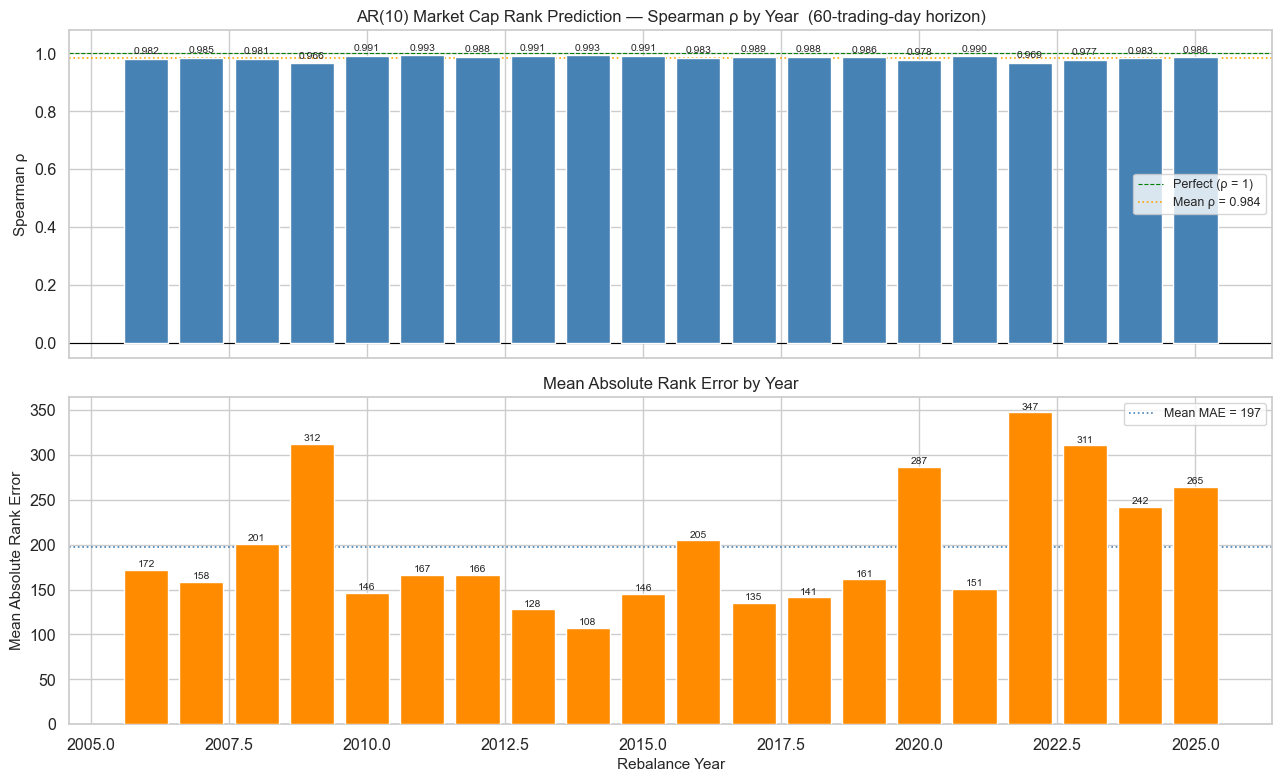

In [ ]:
years = summary.index.tolist()
rhos  = summary['Spearman ρ'].tolist()
maes  = summary['MAE Rank'].tolist()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# — Spearman ρ —
ax = axes[0]
bars = ax.bar(years, rhos, color='steelblue', edgecolor='white', zorder=3)
ax.axhline(0, color='black', lw=0.8, zorder=2)
ax.axhline(1, color='green', lw=0.8, linestyle='--', label='Perfect (ρ = 1)', zorder=2)
ax.axhline(np.mean(rhos), color='orange', lw=1.2, linestyle=':', label=f'Mean ρ = {np.mean(rhos):.3f}', zorder=2)
ax.set_ylabel('Spearman ρ', fontsize=11)
ax.set_title('AR(10) Market Cap Rank Prediction — Spearman ρ by Year  (60-trading-day horizon)', fontsize=12)
ax.set_ylim(-0.05, 1.08)
ax.legend(fontsize=9)
for x, v in zip(years, rhos):
    ax.text(x, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)

# — MAE Rank —
ax = axes[1]
ax.bar(years, maes, color='darkorange', edgecolor='white', zorder=3)
ax.axhline(np.mean(maes), color='steelblue', lw=1.2, linestyle=':', label=f'Mean MAE = {np.mean(maes):.0f}', zorder=2)
ax.set_ylabel('Mean Absolute Rank Error', fontsize=11)
ax.set_xlabel('Rebalance Year', fontsize=11)
ax.set_title('Mean Absolute Rank Error by Year', fontsize=12)
ax.legend(fontsize=9)
for x, v in zip(years, maes):
    ax.text(x, v + 1, f'{v:.0f}', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.show()

### 5.3 Russell Index Membership Overlap

**How to read this chart:** for each Russell index and each year, we ask — of the stocks that *actually* ended up in the index at the target date, what percentage did our predicted ranks also place in that index?

$$\text{Overlap}\% = \frac{|\text{Predicted members} \cap \text{Actual members}|}{|\text{Actual members}|} \times 100$$

This is equivalent to **recall** computed on the full predicted vs actual membership sets (not conditioned on prior membership).

**Why overlap differs across indices:**
- **Russell 1000** (top 1,000): large-cap stocks are stable; even a mediocre model predicts most of them correctly because mega-caps don't fall out of the top 1,000 in 60 days. Expect 85–95% overlap.
- **Russell 2000** (ranks 1,001–3,000): the boundary is much more contested. Stocks near rank 1,000 or 3,000 are volatile in relative terms. Expect 70–85% overlap.
- **Russell Microcap** (ranks 2,001–4,000): highest volatility at the margins; expect the lowest overlap.

In [ ]:
overlap_rows = []
for year, cmp in year_results.items():
    for name, (lo, hi) in RUSSELL_BANDS.items():
        if name == 'Russell 3000':
            pred_in   = set(cmp[cmp['pred_membership'].isin(['Russell 1000', 'Russell 2000'])].index)
            actual_in = set(cmp[cmp['actual_membership'].isin(['Russell 1000', 'Russell 2000'])].index)
        else:
            pred_in   = set(cmp[cmp['pred_membership'] == name].index)
            actual_in = set(cmp[cmp['actual_membership'] == name].index)
        n_actual  = len(actual_in)
        correct   = len(pred_in & actual_in)
        overlap_rows.append({
            'Year':        year,
            'Index':       name,
            'N_Actual':    n_actual,
            'Overlap_Pct': correct / n_actual * 100 if n_actual > 0 else 0,
        })

overlap_df = pd.DataFrame(overlap_rows)

fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharey=True)
for ax, (name, _) in zip(axes.flatten(), RUSSELL_BANDS.items()):
    sub     = overlap_df[overlap_df['Index'] == name]
    mean_ov = sub['Overlap_Pct'].mean()
    ax.bar(sub['Year'], sub['Overlap_Pct'], color='steelblue', edgecolor='white', zorder=3)
    ax.axhline(100,     color='green',  lw=0.8, linestyle='--', label='Perfect (100%)', zorder=2)
    ax.axhline(mean_ov, color='orange', lw=1.2, linestyle=':',  label=f'Mean = {mean_ov:.1f}%', zorder=2)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Year')
    ax.set_ylabel('Membership Overlap (%)')
    ax.set_ylim(0, 112)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)

plt.suptitle(
    'Russell Index Membership Overlap: Predicted vs Actual\n'
    '(% of actual members correctly identified, 60-trading-day horizon)\n'
    '[Membership uses Russell percentile banding rules]',
    fontsize=13
)
plt.tight_layout()
plt.show()


### 5.4 Add/Remove Prediction — Russell 2000

This section focuses on the hardest and most practically relevant question: can the model identify which stocks will **enter or exit the Russell 2000** at this year's reconstitution?

**Setup:** we use the *prior year's rank date* market caps as a proxy for the pre-rebalance index membership. A stock is an "add" if it was outside R2000 a year ago and is inside it at the target date; a "remove" if the reverse.

**Metrics:**
- **Precision** = of the stocks our model predicts as adds (or removes), what fraction actually were? High precision = few false alarms.
- **Recall** = of the stocks that actually were added (or removed), what fraction did we catch? High recall = few misses.

**Why is this hard?** The stocks that actually cross the boundary are precisely the ones that have experienced the most unusual market cap movement in the year — they are the *outliers*. The AR(10) model, which essentially extrapolates the recent trend, has no mechanism to predict outlier moves. It will tend to predict most stocks stay near their current rank, meaning recall for boundary-crossers will be structurally low.

A naive baseline — "predict no changes" — would achieve 100% precision but 0% recall. Anything the AR model produces needs to be judged against this baseline.

In [ ]:
# Ground truth: official Russell reconstitution events (not rank-based proxy)
events = pd.read_csv(PROCESSED_DIR / 'russell_events.csv')

rebal_rows = []
for year, cmp in year_results.items():
    if cmp['prev_rank'].isna().all():
        continue

    yr_adds    = set(events[(events['Year'] == year) & (events['Event_Type'] == 'ADD')   ]['Ticker'])
    yr_deletes = set(events[(events['Year'] == year) & (events['Event_Type'] == 'DELETE')]['Ticker'])
    cmp_idx    = set(cmp.index)

    for name, (lo, hi) in RUSSELL_BANDS.items():
        prev_in = in_band(cmp['prev_rank'], lo, hi)

        if name == 'Russell 3000':
            pred_in = cmp['pred_membership'].isin(['Russell 1000', 'Russell 2000'])
        else:
            pred_in = cmp['pred_membership'] == name

        pred_adds_set    = set(cmp[(~prev_in) & pred_in].index)
        pred_removes_set = set(cmp[prev_in & (~pred_in)].index)

        if name == 'Russell 2000':
            # Official Russell events as ground truth — eliminates rank proxy bias
            actual_adds_set    = yr_adds    & cmp_idx
            actual_removes_set = yr_deletes & cmp_idx
        else:
            # Rank-based for other indices (not shown in primary charts)
            if name == 'Russell 3000':
                actual_in = cmp['actual_membership'].isin(['Russell 1000', 'Russell 2000'])
            else:
                actual_in = cmp['actual_membership'] == name
            actual_adds_set    = set(cmp[(~prev_in) & actual_in].index)
            actual_removes_set = set(cmp[prev_in & (~actual_in)].index)

        tp_adds    = len(pred_adds_set    & actual_adds_set)
        tp_removes = len(pred_removes_set & actual_removes_set)
        n_aa = len(actual_adds_set);    n_pa = len(pred_adds_set)
        n_ar = len(actual_removes_set); n_pr = len(pred_removes_set)

        rebal_rows.append({
            'Year':             year,
            'Index':            name,
            'Actual Adds':      n_aa,
            'Add_Precision':    tp_adds    / n_pa if n_pa > 0 else np.nan,
            'Add_Recall':       tp_adds    / n_aa if n_aa > 0 else np.nan,
            'Actual Removes':   n_ar,
            'Remove_Precision': tp_removes / n_pr if n_pr > 0 else np.nan,
            'Remove_Recall':    tp_removes / n_ar if n_ar > 0 else np.nan,
        })

rebal_df = pd.DataFrame(rebal_rows)

# Focus on Russell 2000
r2k = rebal_df[rebal_df['Index'] == 'Russell 2000'].set_index('Year')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (metric_p, metric_r, label) in zip(axes, [
    ('Add_Precision',    'Add_Recall',    'Adds'),
    ('Remove_Precision', 'Remove_Recall', 'Removes'),
]):
    w = 0.35
    x = np.arange(len(r2k))
    ax.bar(x - w/2, r2k[metric_p] * 100, w, label='Precision', color='steelblue',  alpha=0.85, zorder=3)
    ax.bar(x + w/2, r2k[metric_r] * 100, w, label='Recall',    color='darkorange', alpha=0.85, zorder=3)
    ax.axhline(r2k[metric_p].mean() * 100, color='steelblue',  lw=1.3, linestyle=':',
               label=f'Avg Precision = {r2k[metric_p].mean():.0%}', zorder=2)
    ax.axhline(r2k[metric_r].mean() * 100, color='darkorange', lw=1.3, linestyle=':',
               label=f'Avg Recall = {r2k[metric_r].mean():.0%}', zorder=2)
    ax.set_xticks(x)
    ax.set_xticklabels(r2k.index, rotation=45)
    ax.set_ylabel('%', fontsize=11)
    ax.set_ylim(0, 112)
    ax.set_title(f'Russell 2000 {label}: Precision & Recall by Year', fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle(
    'Russell 2000 Membership Change Prediction  (AR10, 60-day horizon)\n'
    'Ground truth = official Russell ADD/DELETE events (russell_events.csv)',
    fontsize=12
)
plt.tight_layout()
plt.show()

print('Russell 2000 Add/Remove Summary (mean ± std across years):')
print(r2k[['Actual Adds', 'Add_Precision', 'Add_Recall',
           'Actual Removes', 'Remove_Precision', 'Remove_Recall']]
      .agg(['mean', 'std'])
      .applymap(lambda v: f'{v:.1%}' if abs(v) < 10 else f'{v:.0f}'))


### 5.5 Pooled Rank Error Distribution

Aggregating all stock-year pairs gives a single view of the model's accuracy distribution across the entire study period.

The **CDF (Cumulative Distribution Function)** shows the fraction of stock-years where rank error was at or below a given threshold. Key reference points:
- Stocks within ±50 ranks of their actual position are "close enough" to have little impact on index membership decisions.
- Stocks within ±100 ranks matter for the marginal R2000 inclusion band (~ranks 950–1,050 and 2,950–3,050).
- Stocks with errors >500 positions represent complete mispredictions — the model placed them in entirely the wrong part of the size spectrum.

The overall **pooled Spearman ρ** is also reported. This number will look deceptively high because size hierarchy is persistent — AAPL will still be large-cap in August regardless of what any model predicts. The rank error distribution is a more honest measure of practical usefulness.

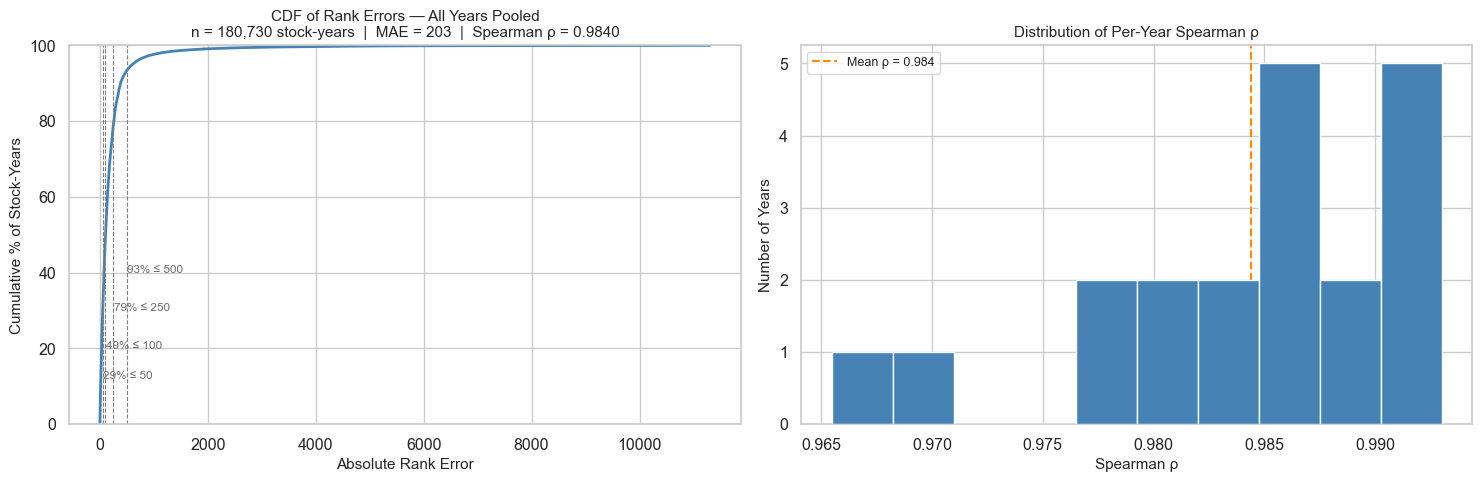

Pooled Spearman ρ : 0.9840
Pooled MAE rank   : 202.8
Stock-years total : 180,730


In [ ]:
all_errors  = pd.concat([cmp['rank_error'] for cmp in year_results.values()])
all_pred    = pd.concat([cmp['predicted']  for cmp in year_results.values()])
all_actual  = pd.concat([cmp['actual']     for cmp in year_results.values()])

pooled_rho, _ = spearmanr(all_pred, all_actual)
pooled_mae    = all_errors.mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# — CDF —
ax = axes[0]
sorted_err = np.sort(all_errors.values)
cdf = np.arange(1, len(sorted_err) + 1) / len(sorted_err) * 100
ax.plot(sorted_err, cdf, color='steelblue', lw=2)
for thresh, ypos in [(50, 12), (100, 20), (250, 30), (500, 40)]:
    pct = (all_errors <= thresh).mean() * 100
    ax.axvline(thresh, color='gray', linestyle='--', lw=0.8)
    ax.text(thresh + 10, ypos, f'{pct:.0f}% ≤ {thresh}', fontsize=8.5, color='dimgray')
ax.set_xlabel('Absolute Rank Error', fontsize=11)
ax.set_ylabel('Cumulative % of Stock-Years', fontsize=11)
ax.set_title(
    f'CDF of Rank Errors — All Years Pooled\n'
    f'n = {len(all_errors):,} stock-years  |  MAE = {pooled_mae:.0f}  |  Spearman ρ = {pooled_rho:.4f}',
    fontsize=11
)
ax.set_ylim(0, 100)

# — Histogram of per-year Spearman ρ for context —
ax = axes[1]
rho_vals = [spearmanr(cmp['predicted'], cmp['actual'])[0] for cmp in year_results.values()]
ax.hist(rho_vals, bins=10, color='steelblue', edgecolor='white', zorder=3)
ax.axvline(np.mean(rho_vals), color='darkorange', lw=1.5, linestyle='--',
           label=f'Mean ρ = {np.mean(rho_vals):.3f}')
ax.set_xlabel('Spearman ρ', fontsize=11)
ax.set_ylabel('Number of Years', fontsize=11)
ax.set_title('Distribution of Per-Year Spearman ρ', fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Pooled Spearman ρ : {pooled_rho:.4f}')
print(f'Pooled MAE rank   : {pooled_mae:.1f}')
print(f'Stock-years total : {len(all_errors):,}')